In [12]:
import pandas as pd
# dados normalizados sem outliers
df = pd.read_parquet("../df_normal.parquet")


### Neural Network

In [13]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import KFold, cross_validate, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

df_rede = df.copy()
X_rede = df_rede.drop(columns=["exam_score"], errors="ignore")
y_rede = df_rede["exam_score"]

# K-Fold 5
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Rede
rede = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=300,
    early_stopping=True,
    random_state=42
)

# Validação cruzada
resultados = cross_validate(
    rede,
    X_rede,
    y_rede,
    cv=kfold,
    scoring=["r2", "neg_mean_absolute_error", "neg_root_mean_squared_error"],
    n_jobs=-1
)

print("R2 por fold:", resultados["test_r2"])
print("R2 médio:", resultados["test_r2"].mean())

print("MAE médio:", -resultados["test_neg_mean_absolute_error"].mean())
print("RMSE médio:", -resultados["test_neg_root_mean_squared_error"].mean())

R2 por fold: [0.80470099 0.80534297 0.80416296 0.80540285 0.80677552]
R2 médio: 0.8052770575001971
MAE médio: 0.3562856381256075
RMSE médio: 0.44126966784331795


Análise dos pressupostos (neural network)

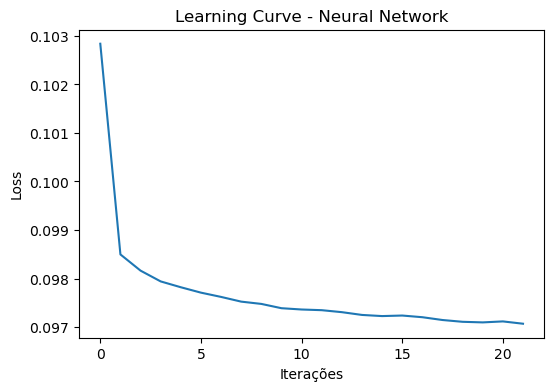

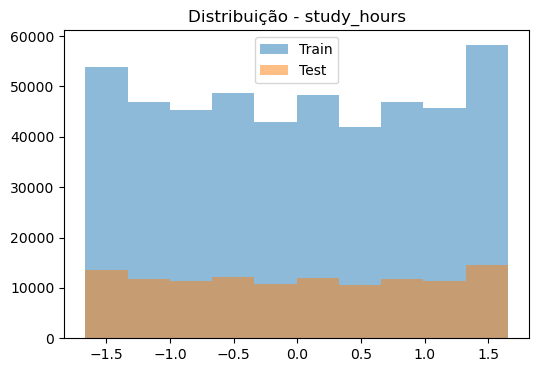

Durbin-Watson: 1.9971825387376867
Sem autocorrelação relevante


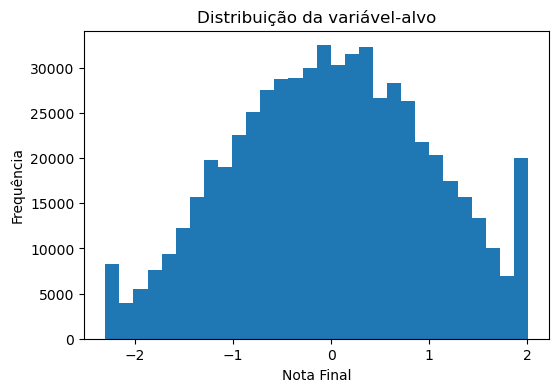

In [14]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from statsmodels.stats.stattools import durbin_watson
import matplotlib.pyplot as plt

# =========================================================
# 1. Padrões aprendíveis
# =========================================================

#Treinar modelo separadamente
rede_fit = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=300,
    early_stopping=True,
    random_state=42
)

rede_fit.fit(X_rede, y_rede)

#Curva de loss
plt.figure(figsize=(6,4))
plt.plot(rede_fit.loss_curve_)
plt.xlabel("Iterações")
plt.ylabel("Loss")
plt.title("Learning Curve - Neural Network")
plt.show()

# =========================================================
# 2. Distribuições semelhantes
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_rede,
    y_rede,
    test_size=0.2,
    random_state=42
)

#gráfico para todas as colunas
"""for col in X_rede.columns:
    plt.figure(figsize=(6,4))
    plt.hist(X_train[col], alpha=0.5, label="Train")
    plt.hist(X_test[col], alpha=0.5, label="Test")
    plt.title(f"Distribuição - {col}")
    plt.legend()
    plt.show()"""

#exemplo
col = "study_hours"
plt.figure(figsize=(6,4))
plt.hist(X_train[col], alpha=0.5, label="Train")
plt.hist(X_test[col], alpha=0.5, label="Test")
plt.title(f"Distribuição - {col}")
plt.legend()
plt.show()

# =========================================================
# 3. Observações aproximadamente independentes
# =========================================================  

#Treinar modelo
rede_fit.fit(X_train, y_train)
y_pred = rede_fit.predict(X_test)
residuos = y_test - y_pred

dw = durbin_watson(residuos)
print("Durbin-Watson:", dw)

if 1.5 < dw < 2.5:
    print("Sem autocorrelação relevante")
else:
    print("Possível autocorrelação")

# =========================================================
# 4. Dados representativos
# ========================================================= 

plt.figure(figsize=(6,4))
plt.hist(y_rede, bins=30)
plt.xlabel("Nota Final")
plt.ylabel("Frequência")
plt.title("Distribuição da variável-alvo")
plt.show()

### Regressão Ridge

In [2]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_validate
import pandas as pd

df_ridge = df.copy()

X_ridge = df_ridge.drop(columns=["exam_score"], errors="ignore")
y_ridge = df_ridge["exam_score"]

# K-Fold 5
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Modelo Ridge Regression
modelo_ridge = Ridge(
    alpha=1.0,
    random_state=42
)

# Validação cruzada
resultados_ridge = cross_validate(
    modelo_ridge,
    X_ridge,
    y_ridge,
    cv=kfold,
    scoring=[
        "r2",
        "explained_variance",
        "neg_mean_absolute_error",
        "neg_mean_squared_error",
        "neg_root_mean_squared_error",
        "neg_median_absolute_error",
        "max_error"
    ],
    n_jobs=-1,
    return_train_score=True
)
# Resultados por fold
print("R2 por fold:", resultados_ridge["test_r2"])

# Médias das métricas
print("R2 médio:", resultados_ridge["test_r2"].mean())

print("Explained Variance média:",
      resultados_ridge["test_explained_variance"].mean())

print("MAE médio:",
      -resultados_ridge["test_neg_mean_absolute_error"].mean())

print("MSE médio:",
      -resultados_ridge["test_neg_mean_squared_error"].mean())

print("RMSE médio:",
      -resultados_ridge["test_neg_root_mean_squared_error"].mean())

print("Median Absolute Error médio:",
      -resultados_ridge["test_neg_median_absolute_error"].mean())

print("Max Error médio:",
      resultados_ridge["test_max_error"].mean())

R2 por fold: [0.80435161 0.80405061 0.80282318 0.80487595 0.80598768]
R2 médio: 0.804417806263307
Explained Variance média: 0.804418306489343
MAE médio: 0.35716486166006317
MSE médio: 0.1955774416053509
RMSE médio: 0.4422409702517949
Median Absolute Error médio: 0.3085565693493882
Max Error médio: -1.859150326453069


Análise dos resíduos

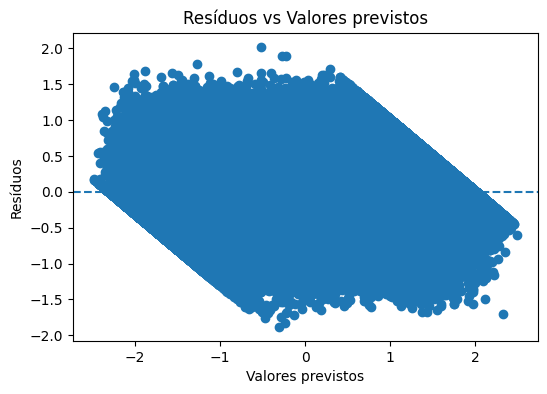

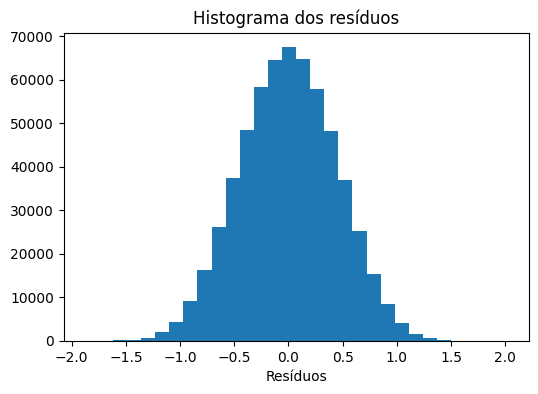

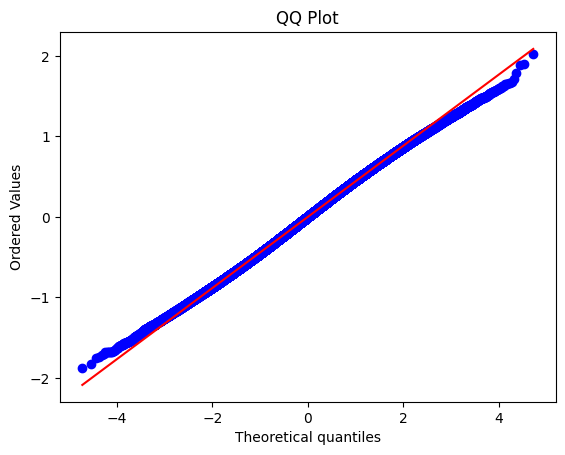

C:\Users\maria\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 598500.
  res = hypotest_fun_out(*samples, **kwds)



--- Normalidade ---
p-value Shapiro: 1.4244445248001248e-32
Resíduos NÃO normais

--- Homocedasticidade ---
p-value Breusch-Pagan: 7.772766788265573e-259
Possível heterocedasticidade

--- Independência dos erros ---
Durbin-Watson: 2.0033107019716603
Sem autocorrelação relevante


C:\Users\maria\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)



--- VIF ---
                        Variável           VIF
0                    study_hours           inf
1                internet_access  1.000839e+00
2                    sleep_hours  4.846406e+00
3           sleep_quality_mapped  1.748741e+01
4         facility_rating_mapped  1.002956e+00
5         exam_difficulty_mapped  3.886619e+00
6       study_method_group study  1.576351e+00
7             study_method_mixed  1.574666e+00
8     study_method_online videos  1.565696e+00
9        study_method_self-study  1.598541e+00
10                   course_b.sc  1.649509e+00
11                 course_b.tech  1.729023e+00
12                     course_ba  1.403863e+00
13                    course_bba  1.477599e+00
14                    course_bca  1.543838e+00
15                course_diploma  1.333132e+00
16                   gender_male  1.340492e+00
17                  gender_other  1.340497e+00
18              total_study_time  2.583318e+08
19                 sleep_balance  2.087861e+10


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm

from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor

# =========================================================
# AJUSTAR O MODELO RIDGE QUE JÁ TENS
# =========================================================

modelo_ridge.fit(X_ridge, y_ridge)

# Previsões
y_pred = modelo_ridge.predict(X_ridge)

# Resíduos
residuos = y_ridge - y_pred

# =========================================================
# 1. LINEARIDADE
# =========================================================

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuos)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Valores previstos")
plt.ylabel("Resíduos")
plt.title("Resíduos vs Valores previstos")
plt.show()

# =========================================================
# 2. NORMALIDADE DOS RESÍDUOS
# =========================================================

# Histograma
plt.figure(figsize=(6,4))
plt.hist(residuos, bins=30)
plt.title("Histograma dos resíduos")
plt.xlabel("Resíduos")
plt.show()

# QQ Plot
stats.probplot(residuos, dist="norm", plot=plt)
plt.title("QQ Plot")
plt.show()

# Shapiro-Wilk
shapiro_stat, shapiro_p = stats.shapiro(residuos)

print("\n--- Normalidade ---")
print("p-value Shapiro:", shapiro_p)

if shapiro_p > 0.05:
    print("Resíduos aproximadamente normais")
else:
    print("Resíduos NÃO normais")

# =========================================================
# 3. HOMOCEDASTICIDADE
# =========================================================

X_const = sm.add_constant(X_ridge)

bp_test = het_breuschpagan(residuos, X_const)

print("\n--- Homocedasticidade ---")
print("p-value Breusch-Pagan:", bp_test[1])

if bp_test[1] > 0.05:
    print("Homocedasticidade verificada")
else:
    print("Possível heterocedasticidade")

# =========================================================
# 4. INDEPENDÊNCIA DOS ERROS
# =========================================================

dw = durbin_watson(residuos)

print("\n--- Independência dos erros ---")
print("Durbin-Watson:", dw)

if 1.5 < dw < 2.5:
    print("Sem autocorrelação relevante")
else:
    print("Possível autocorrelação")

# =========================================================
# 5. MULTICOLINEARIDADE
# =========================================================

vif_df = pd.DataFrame()
vif_df["Variável"] = X_ridge.columns

vif_df["VIF"] = [
    variance_inflation_factor(X_ridge.values, i)
    for i in range(X_ridge.shape[1])
]

print("\n--- VIF ---")
print(vif_df)

print("\nInterpretação:")
print("VIF < 5  -> OK")
print("VIF 5-10 -> Moderado")
print("VIF > 10 -> Multicolinearidade forte")

Novo Ridge

In [4]:
# =========================================================
# REMOVER VARIÁVEIS COM MULTICOLINEARIDADE ELEVADA
# =========================================================

X_ridge_reduzido = X_ridge.drop(columns=[
    "total_study_time",
    "sleep_balance",
    "study_sleep_ratio",
    "log_study_hours"
])

# =========================================================
# RECALCULAR VIF
# =========================================================

import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_resultados = pd.DataFrame()

vif_resultados["feature"] = X_ridge_reduzido.columns

vif_resultados["VIF"] = [
    variance_inflation_factor(X_ridge_reduzido.values, indice)
    for indice in range(X_ridge_reduzido.shape[1])
]

# Mostrar resultados
print(vif_resultados.sort_values(by="VIF", ascending=False))

C:\Users\maria\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                         feature           VIF
0                    study_hours           inf
19  study_attendance_interaction           inf
23                  study_effort           inf
18           study_hours_squared           inf
24                  rest_balance  4.731293e+10
20          sleep_quality_effect  1.657150e+09
21                study_vs_sleep  2.047570e+01
3           sleep_quality_mapped  1.748729e+01
25              study_difficulty  5.799875e+00
2                    sleep_hours  4.842163e+00
5         exam_difficulty_mapped  3.886537e+00
22           attendance_residual  3.884526e+00
11                 course_b.tech  1.728122e+00
10                   course_b.sc  1.649290e+00
9        study_method_self-study  1.598411e+00
6       study_method_group study  1.576287e+00
7             study_method_mixed  1.574097e+00
8     study_method_online videos  1.565625e+00
14                    course_bca  1.543821e+00
13                    course_bba  1.477578e+00
12           

In [5]:
import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, KFold

# =========================================================
# NOVO X (APÓS REMOÇÃO DE MULTICOLINEARIDADE)
# =========================================================

X_ridge_reduzido = X_ridge.drop(columns=[
    "total_study_time",
    "sleep_balance",
    "study_sleep_ratio",
    "log_study_hours"
])

# =========================================================
# MODELO RIDGE (COM SCALING)
# =========================================================

modelo_ridge_novo = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

# =========================================================
# CROSS-VALIDATION
# =========================================================

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

resultados_ridge_novo = cross_validate(
    modelo_ridge_novo,
    X_ridge_reduzido,
    y_ridge,
    cv=kfold,
    scoring=[
        "r2",
        "explained_variance",
        "neg_mean_absolute_error",
        "neg_mean_squared_error",
        "neg_root_mean_squared_error",
        "neg_median_absolute_error",
        "max_error"
    ],
    n_jobs=-1,
    return_train_score=True
)

# =========================================================
# RESULTADOS
# =========================================================

print("R2 por fold:", resultados_ridge_novo["test_r2"])
print("R2 médio:", resultados_ridge_novo["test_r2"].mean())

print("Explained Variance médio:",
      resultados_ridge_novo["test_explained_variance"].mean())

print("MAE médio:",
      -resultados_ridge_novo["test_neg_mean_absolute_error"].mean())

print("MSE médio:",
      -resultados_ridge_novo["test_neg_mean_squared_error"].mean())

print("RMSE médio:",
      -resultados_ridge_novo["test_neg_root_mean_squared_error"].mean())

print("Median AE médio:",
      -resultados_ridge_novo["test_neg_median_absolute_error"].mean())

print("Max Error médio:",
      resultados_ridge_novo["test_max_error"].mean())

R2 por fold: [0.80427305 0.8040124  0.80271854 0.80478705 0.80591591]
R2 médio: 0.8043413899253979
Explained Variance médio: 0.8043419336232688
MAE médio: 0.35717873879121953
MSE médio: 0.19565382168328962
RMSE médio: 0.4423273186088491
Median AE médio: 0.30850100922161566
Max Error médio: -1.858782779706774


### XGBoost

In [15]:
from xgboost import XGBRegressor
from sklearn.model_selection import KFold, cross_validate
import pandas as pd

df_xgb = df.copy()

X_xgb = df_xgb.drop(columns=["exam_score"], errors="ignore")
y_xgb = df_xgb["exam_score"]

# K-Fold 5
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

modelo_xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

# Validação 
resultados_xgb = cross_validate(
    modelo_xgb,
    X_xgb,
    y_xgb,
    cv=kfold,
    scoring=[
        "r2",
        "neg_mean_absolute_error",
        "neg_root_mean_squared_error"
    ],
    n_jobs=-1
)

# Resultados
print("R2 por fold:", resultados_xgb["test_r2"])
print("R2 médio:", resultados_xgb["test_r2"].mean())
print("MAE médio:", -resultados_xgb["test_neg_mean_absolute_error"].mean())
print("RMSE médio:", -resultados_xgb["test_neg_root_mean_squared_error"].mean())

R2 por fold: [0.80576769 0.80633994 0.80511325 0.80584526 0.80746746]
R2 médio: 0.8061067201796632
MAE médio: 0.3562504781754895
RMSE médio: 0.4403287735316085


Análise dos pressupostos (xgboost)

<Figure size 800x600 with 0 Axes>

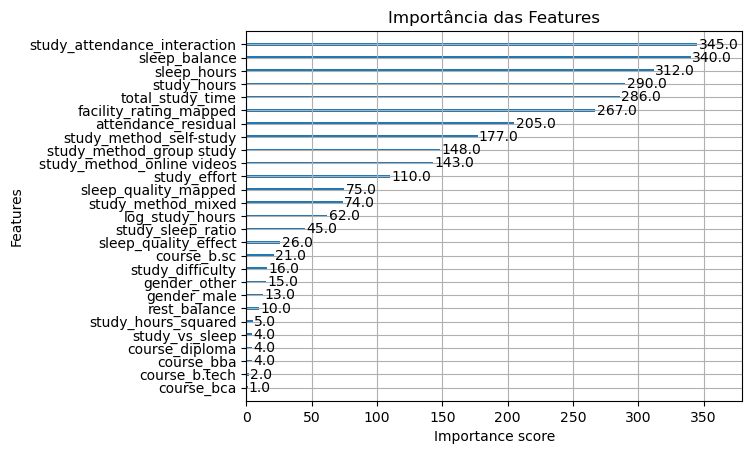

Durbin-Watson: 2.002468804179913
Sem autocorrelação relevante
study_hours                     float64
internet_access                 float64
sleep_hours                     float64
sleep_quality_mapped            float64
facility_rating_mapped          float64
exam_difficulty_mapped          float64
study_method_group study        float64
study_method_mixed              float64
study_method_online videos      float64
study_method_self-study         float64
course_b.sc                     float64
course_b.tech                   float64
course_ba                       float64
course_bba                      float64
course_bca                      float64
course_diploma                  float64
gender_male                     float64
gender_other                    float64
total_study_time                float64
sleep_balance                   float64
study_sleep_ratio               float64
log_study_hours                 float64
study_hours_squared             float64
study_attendance_i

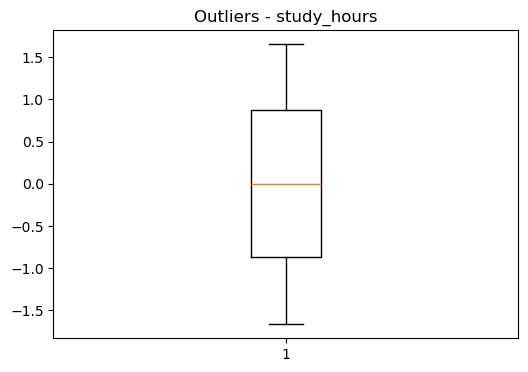

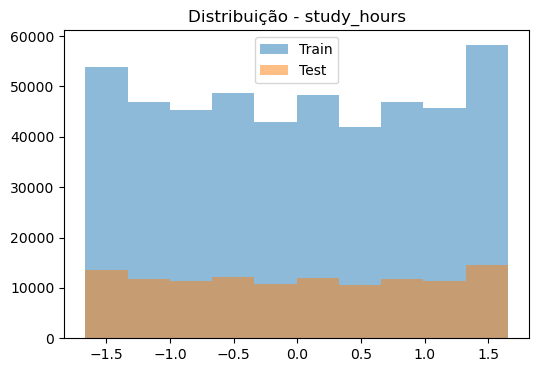

In [16]:
import matplotlib.pyplot as plt

from xgboost import plot_importance
from statsmodels.stats.stattools import durbin_watson
from sklearn.model_selection import train_test_split

# =========================================================
# Ajuste do modelo
# =========================================================

modelo_xgb.fit(X_xgb, y_xgb)

y_pred = modelo_xgb.predict(X_xgb)
residuos = y_xgb - y_pred

# =========================================================
# 1. Features informativas e relevantes
# =========================================================

# Plot importância
plt.figure(figsize=(8,6))
plot_importance(modelo_xgb)
plt.title("Importância das Features")
plt.show()

# =========================================================
# 2. Observações independentes
# =========================================================

dw = durbin_watson(residuos)
print("Durbin-Watson:", dw)

if 1.5 < dw < 2.5:
    print("Sem autocorrelação relevante")
else:
    print("Possível autocorrelação")

# =========================================================
# 3. Dados numéricos
# =========================================================

print(X_xgb.dtypes)

# =========================================================
# 4. Robustez a outliers e ruído
# =========================================================

#gráfico para todas as colunas
"""for col in X_xgb.columns:
    plt.figure(figsize=(6,4))
    plt.boxplot(X_xgb[col])
    plt.title(f"Outliers - {col}")
    plt.show()"""

#exemplo
col="study_hours"
plt.figure(figsize=(6,4))
plt.boxplot(X_xgb[col])
plt.title(f"Outliers - {col}")
plt.show()

# =========================================================
# 5. Distribuição semelhante
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_xgb,
    y_xgb,
    test_size=0.2,
    random_state=42
)

#gráfico para todas as colunas
"""for col in X_xgb.columns:
    plt.figure(figsize=(6,4))
    plt.hist(X_train[col], alpha=0.5, label="Train")
    plt.hist(X_test[col], alpha=0.5, label="Test")
    plt.title(f"Distribuição - {col}")
    plt.legend()
    plt.show()"""

#exemplo
plt.figure(figsize=(6,4))
plt.hist(X_train[col], alpha=0.5, label="Train")
plt.hist(X_test[col], alpha=0.5, label="Test")
plt.title(f"Distribuição - {col}")
plt.legend()
plt.show()

In [17]:
#normalidade dos dados
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_xgb)
print("Dados normalizados com sucesso")

Dados normalizados com sucesso


### Bayesian Ridge

In [18]:
from sklearn.linear_model import BayesianRidge
from sklearn.model_selection import KFold, cross_validate
import pandas as pd

df_bayes = df.copy()

X_bayes = df_bayes.drop(columns=["exam_score"], errors="ignore")
y_bayes = df_bayes["exam_score"]

# K-Fold 5
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Modelo Bayesiano
modelo_bayes = BayesianRidge()

# Validação cruzada
resultados_bayes = cross_validate(
    modelo_bayes,
    X_bayes,
    y_bayes,
    cv=kfold,
    scoring=[
        "r2",
        "neg_mean_absolute_error",
        "neg_root_mean_squared_error"
    ],
    n_jobs=-1
)

# Métricas
print("R2 por fold:", resultados_bayes["test_r2"])
print("R2 médio:", resultados_bayes["test_r2"].mean())
print("MAE médio:", -resultados_bayes["test_neg_mean_absolute_error"].mean())
print("RMSE médio:", -resultados_bayes["test_neg_root_mean_squared_error"].mean())

R2 por fold: [0.80403002 0.80461056 0.8033127  0.80428823 0.80584642]
R2 médio: 0.8044175872129165
MAE médio: 0.3571645030202236
RMSE médio: 0.44224249673897126


Análise dos pressupostos (bayesian ridge)

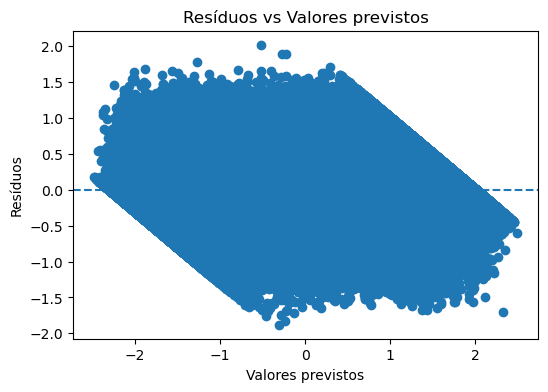

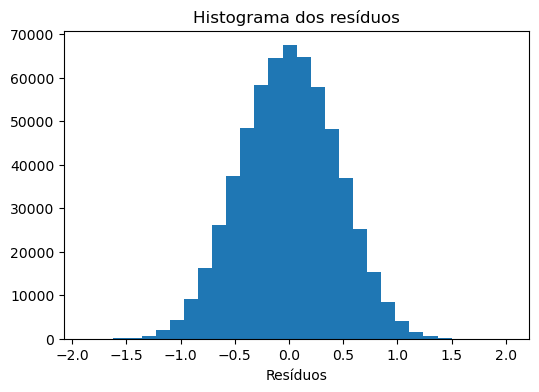

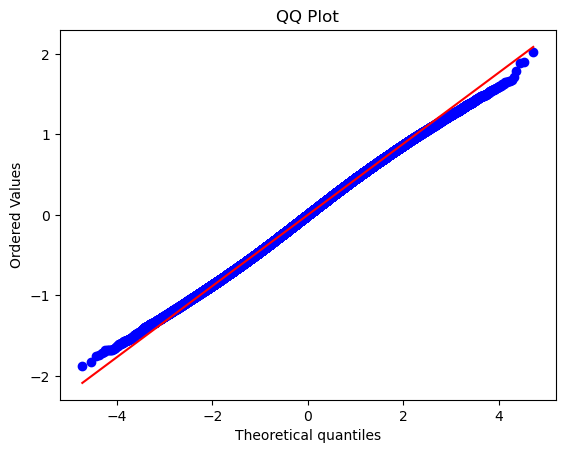

c:\Users\perei\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 598500.
  res = hypotest_fun_out(*samples, **kwds)


p-value Shapiro: 1.4381288793402107e-32
Resíduos NÃO normais
p-value Breusch-Pagan: 6.494674479165307e-259
Possível heterocedasticidade
Durbin-Watson: 2.0033123630750818
Sem autocorrelação relevante


c:\Users\perei\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                        Variável           VIF
0                    study_hours           inf
1                internet_access  1.000839e+00
2                    sleep_hours  4.846419e+00
3           sleep_quality_mapped  1.748425e+01
4         facility_rating_mapped  1.002788e+00
5         exam_difficulty_mapped  3.886612e+00
6       study_method_group study  1.576351e+00
7             study_method_mixed  1.574660e+00
8     study_method_online videos  1.565691e+00
9        study_method_self-study  1.598532e+00
10                   course_b.sc  1.649519e+00
11                 course_b.tech  1.729020e+00
12                     course_ba  1.403863e+00
13                    course_bba  1.477599e+00
14                    course_bca  1.543774e+00
15                course_diploma  1.333138e+00
16                   gender_male  1.340495e+00
17                  gender_other  1.340499e+00
18              total_study_time           inf
19                 sleep_balance           inf
20           

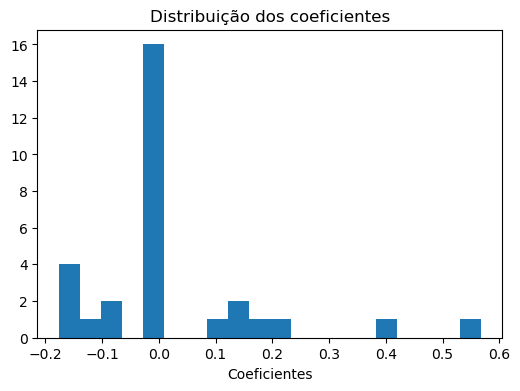

                 0             1             2             3             4   \
count  5.985000e+05  5.985000e+05  5.985000e+05  5.985000e+05  5.985000e+05   
mean   1.549897e-17  1.895671e-17  1.881721e-17 -6.807439e-17  7.833185e-17   
std    1.000001e+00  1.000001e+00  1.000001e+00  1.000001e+00  1.000001e+00   
min   -1.664701e+00 -3.383911e+00 -1.712234e+00 -1.218310e+00 -1.214348e+00   
25%   -8.639437e-01  2.955161e-01 -8.485611e-01 -1.218310e+00 -1.214348e+00   
50%    3.659330e-04  2.955161e-01  1.511159e-02 -1.770720e-04  1.858150e-02   
75%    8.689124e-01  2.955161e-01  8.787843e-01  1.217956e+00  1.251511e+00   
max    1.652723e+00  2.955161e-01  1.627301e+00  1.217956e+00  1.251511e+00   

                 5             6             7             8             9   \
count  5.985000e+05  5.985000e+05  5.985000e+05  5.985000e+05  5.985000e+05   
mean   2.941896e-17  4.079239e-17  1.145654e-17 -2.827924e-17 -1.430583e-17   
std    1.000001e+00  1.000001e+00  1.000001e+00  1.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm

from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

# =========================================================
# AJUSTAR MODELO
# =========================================================

modelo_bayes.fit(X_bayes, y_bayes)

y_pred = modelo_bayes.predict(X_bayes)
residuos = y_bayes - y_pred

# =========================================================
# 1. Linearidade
# =========================================================

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuos)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Valores previstos")
plt.ylabel("Resíduos")
plt.title("Resíduos vs Valores previstos")
plt.show()

# =========================================================
# 2. Normalidade dos resíduos
# =========================================================

#histograma
plt.figure(figsize=(6,4))
plt.hist(residuos, bins=30)
plt.title("Histograma dos resíduos")
plt.xlabel("Resíduos")
plt.show()

#QQ plot
stats.probplot(residuos, dist="norm", plot=plt)
plt.title("QQ Plot")
plt.show()

#shapiro wilk
shapiro_stat, shapiro_p = stats.shapiro(residuos)
print("p-value Shapiro:", shapiro_p)

if shapiro_p > 0.05:
    print("Resíduos aproximadamente normais")
else:
    print("Resíduos NÃO normais")

# =========================================================
# 3. Homocedasticidade
# =========================================================

X_const = sm.add_constant(X_bayes)
bp_test = het_breuschpagan(residuos, X_const)
print("p-value Breusch-Pagan:", bp_test[1])

if bp_test[1] > 0.05:
    print("Homocedasticidade verificada")
else:
    print("Possível heterocedasticidade")

# =========================================================
# 4. Independência dos erros
# =========================================================

dw = durbin_watson(residuos)
print("Durbin-Watson:", dw)

if 1.5 < dw < 2.5:
    print("Sem autocorrelação relevante")
else:
    print("Possível autocorrelação")

# =========================================================
# 5. Multicolinearidade
# =========================================================

vif_df = pd.DataFrame()
vif_df["Variável"] = X_bayes.columns

vif_df["VIF"] = [
    variance_inflation_factor(X_bayes.values, i)
    for i in range(X_bayes.shape[1])
]

print(vif_df)

# =========================================================
# 6. Distribuição gaussiana dos coeficientes
# =========================================================

coeficientes = modelo_bayes.coef_

plt.figure(figsize=(6,4))
plt.hist(coeficientes, bins=20)
plt.title("Distribuição dos coeficientes")
plt.xlabel("Coeficientes")
plt.show()

# =========================================================
# 7. Normalização dos dados
# =========================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_bayes)

print(pd.DataFrame(X_scaled).describe())

### KNN

In [20]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import KFold, cross_validate
import pandas as pd

df_knn = df.copy()

X_knn = df_knn.drop(columns=["exam_score"], errors="ignore")
y_knn = df_knn["exam_score"]

# K-Fold 5
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Modelo KNN
modelo_knn = KNeighborsRegressor(
    n_neighbors=5,
    weights="distance"
)

# Validação cruzada
resultados_knn = cross_validate(
    modelo_knn,
    X_knn,
    y_knn,
    cv=kfold,
    scoring=[
        "r2",
        "neg_mean_absolute_error",
        "neg_root_mean_squared_error"
    ],
    n_jobs=-1
)

# Métricas
print("R2 por fold:", resultados_knn["test_r2"])
print("R2 médio:", resultados_knn["test_r2"].mean())
print("MAE médio:", -resultados_knn["test_neg_mean_absolute_error"].mean())
print("RMSE médio:", -resultados_knn["test_neg_root_mean_squared_error"].mean())

R2 por fold: [0.75248052 0.75179458 0.75133254 0.75094031 0.75398201]
R2 médio: 0.7521059897055447
MAE médio: 0.3998074129607701
RMSE médio: 0.49788429638452225


Análise dos pressupostos (knn)

                 0             1             2             3             4   \
count  5.985000e+05  5.985000e+05  5.985000e+05  5.985000e+05  5.985000e+05   
mean   1.549897e-17  1.895671e-17  1.881721e-17 -6.807439e-17  7.833185e-17   
std    1.000001e+00  1.000001e+00  1.000001e+00  1.000001e+00  1.000001e+00   
min   -1.664701e+00 -3.383911e+00 -1.712234e+00 -1.218310e+00 -1.214348e+00   
25%   -8.639437e-01  2.955161e-01 -8.485611e-01 -1.218310e+00 -1.214348e+00   
50%    3.659330e-04  2.955161e-01  1.511159e-02 -1.770720e-04  1.858150e-02   
75%    8.689124e-01  2.955161e-01  8.787843e-01  1.217956e+00  1.251511e+00   
max    1.652723e+00  2.955161e-01  1.627301e+00  1.217956e+00  1.251511e+00   

                 5             6             7             8             9   \
count  5.985000e+05  5.985000e+05  5.985000e+05  5.985000e+05  5.985000e+05   
mean   2.941896e-17  4.079239e-17  1.145654e-17 -2.827924e-17 -1.430583e-17   
std    1.000001e+00  1.000001e+00  1.000001e+00  1.

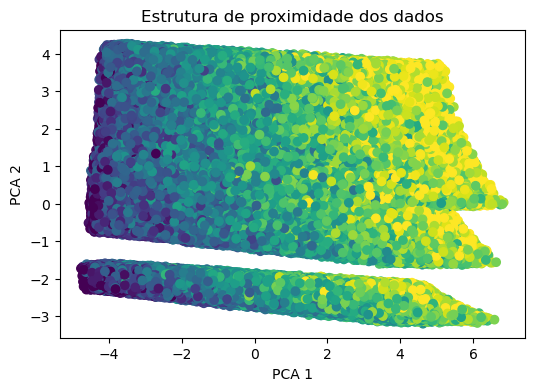

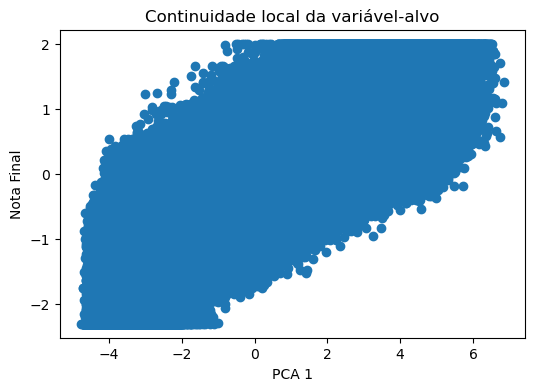

study_attendance_interaction    0.826291
study_hours                     0.790796
log_study_hours                 0.763767
study_hours_squared             0.763318
study_sleep_ratio               0.671854
study_vs_sleep                  0.671854
total_study_time                0.473714
study_difficulty                0.455765
attendance_residual             0.303576
study_effort                    0.254155
rest_balance                    0.247494
sleep_quality_effect            0.247494
sleep_balance                   0.247494
sleep_quality_mapped            0.216737
sleep_hours                     0.173084
facility_rating_mapped          0.170047
study_method_mixed              0.066259
course_bba                      0.013872
gender_other                    0.010072
exam_difficulty_mapped          0.008817
course_bca                      0.001521
course_b.tech                   0.001094
internet_access                 0.000651
course_diploma                 -0.002679
course_b.sc     

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.stats.stattools import durbin_watson
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# =========================================================
# AJUSTAR MODELO
# =========================================================

scaler = StandardScaler()

X_knn_scaled = scaler.fit_transform(X_knn)

# =========================================================
# 1. Dados Normalizados
# =========================================================

scaler = StandardScaler()
X_knn_scaled = scaler.fit_transform(X_knn)
df_scaled = pd.DataFrame(X_knn_scaled)

print(df_scaled.describe())

# =========================================================
# 2. Similaridade capturada pela distância euclidiana
# =========================================================

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_knn_scaled)

plt.figure(figsize=(6,4))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_knn
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Estrutura de proximidade dos dados")
plt.show()

# =========================================================
# 3. Continuidade local da variável-alvo
# =========================================================

plt.figure(figsize=(6,4))
plt.scatter(X_pca[:,0], y_knn)
plt.xlabel("PCA 1")
plt.ylabel("Nota Final")
plt.title("Continuidade local da variável-alvo")
plt.show()

# =========================================================
# 4. Ausência de features irrelevantes
# =========================================================

correlacoes = X_knn.corrwith(y_knn)
print(correlacoes.sort_values(ascending=False))

# =========================================================
# 5. Observações independentes
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_knn_scaled,
    y_knn,
    test_size=0.2,
    random_state=42
)

modelo_knn.fit(X_train, y_train)
y_pred = modelo_knn.predict(X_test)
residuos = y_test - y_pred

dw = durbin_watson(residuos)

print("Durbin-Watson:", dw)

if 1.5 < dw < 2.5:
    print("Sem autocorrelação relevante")
else:
    print("Possível autocorrelação")